<a href="https://colab.research.google.com/github/Anurag-cmd-ai/Titanic_Dataset_EDA/blob/main/Titanic_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv("/content/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#Inspecting data -->

Correcting Datatypes,handling Missing and Null values

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            714 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Cabin          891 non-null    object 
 11  Embarked       891 non-null    object 
 12  FamilySize     891 non-null    int64  
 13  FamilyType     891 non-null    object 
 14  FarePerPerson  891 non-null    float64
 15  Deck           891 non-null    object 
dtypes: float64(3), int64(6), object(7)
memory usage: 111.5+ KB


In [136]:
df['Age'].isnull().sum()

np.int64(177)

<Axes: ylabel='Density'>

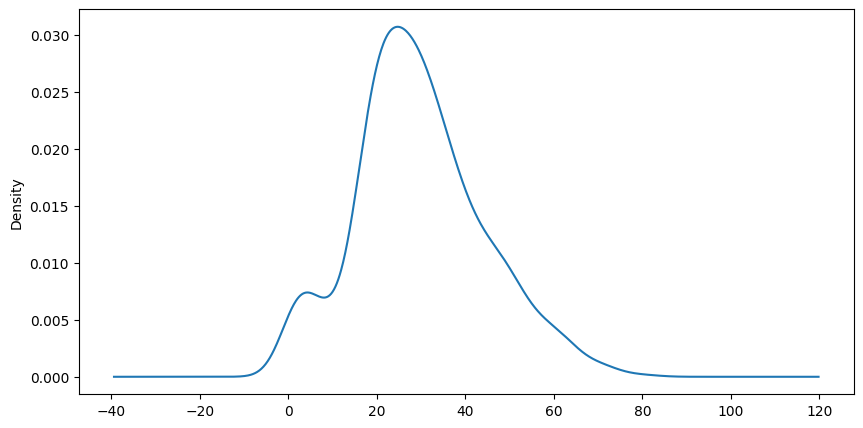

In [138]:
df['Age'].plot(kind='kde',figsize=(10,5))

Since age follows almost a normal distribution we can fill the null values with mean values

In [143]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Age']=df['Age'].astype(int)
df['Cabin'].fillna('M')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            891 non-null    int64  
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Cabin          891 non-null    object 
 11  Embarked       891 non-null    object 
 12  FamilySize     891 non-null    int64  
 13  FamilyType     891 non-null    object 
 14  FarePerPerson  891 non-null    float64
 15  Deck           891 non-null    object 
dtypes: float64(2), int64(7), object(7)
memory usage: 111.5+ KB


#Univariate Analysis

#Age column

In [7]:

df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


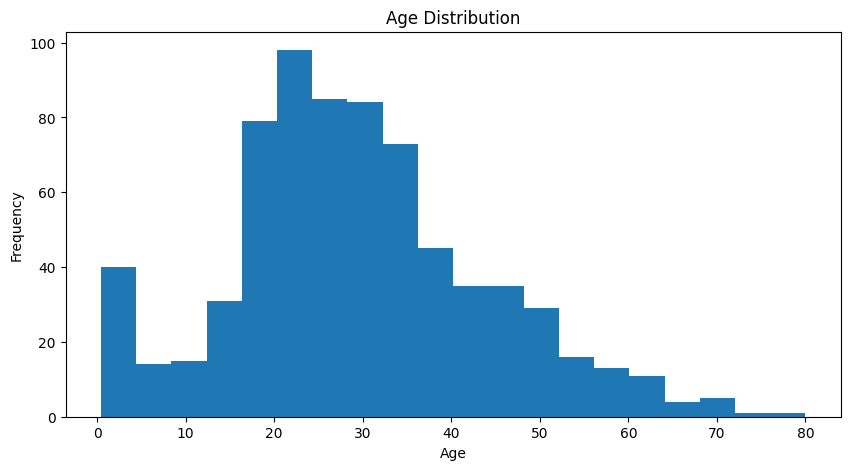

In [8]:
df['Age'].plot(kind='hist',bins=20,figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()


We conclude that most number of people are more likely form age group 20-30 .

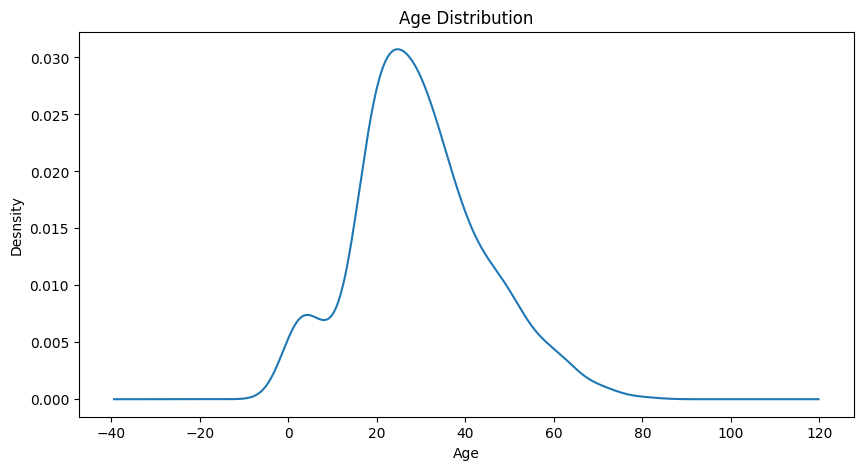

In [9]:
df['Age'].plot(kind='kde',figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('Desnsity')
plt.title('Age Distribution')
plt.show()

In [10]:
df['Age'].skew()

np.float64(0.38910778230082704)

By the plot we conclude that age group follows a approx. normal distibution

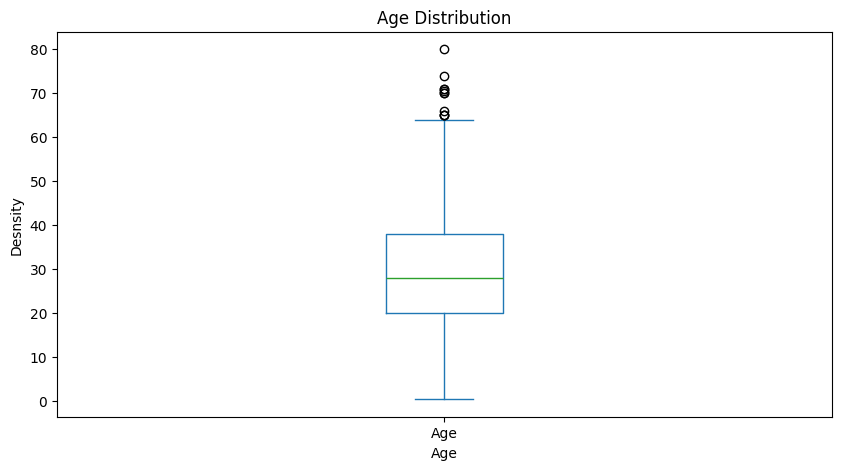

In [11]:
df['Age'].plot(kind='box',figsize=(10,5))
plt.xlabel('Age')
plt.ylabel('Desnsity')
plt.title('Age Distribution')
plt.show()

By the plot we can conclude our age data includes some extreme values such as 80 that is a valid age ,therefore data is valid

#null values in Age



In [12]:
df['Age'].isnull().sum()

np.int64(177)

In [13]:
df['Age'].isnull().sum()/df.shape[0]*100

np.float64(19.865319865319865)

Age Column has 19% missing values ,that needs to be treated

#Fair Column


In [14]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


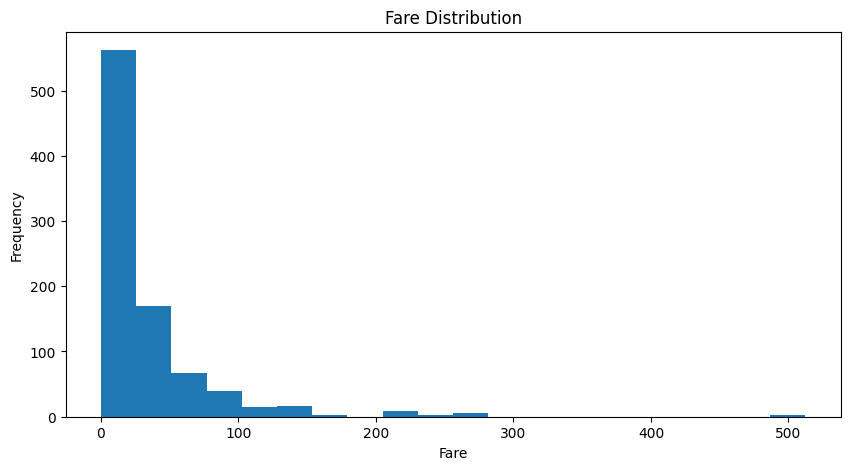

In [15]:
df['Fare'].plot(kind='hist',bins=20,figsize=(10,5))
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Fare Distribution')
plt.show()

By the plot we conclude that most people are travelling with fare value range from 0-25 dollars,with around 50 percent people having less than 14 dollars  as fare price.





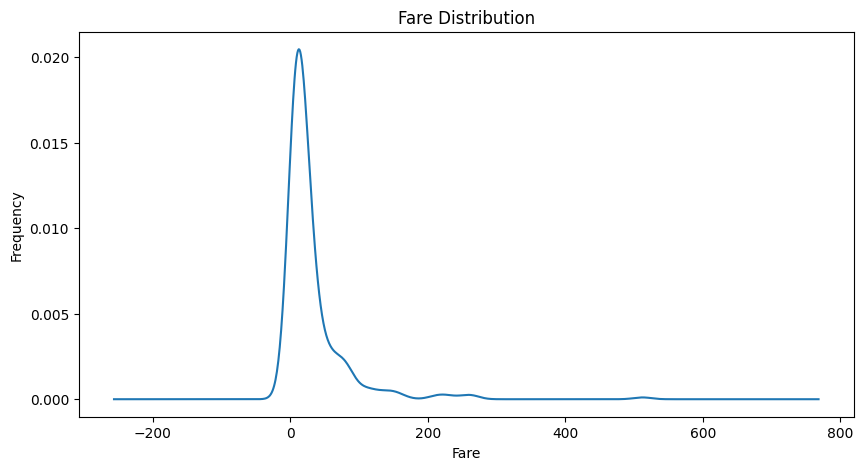

In [16]:
df['Fare'].plot(kind='kde',figsize=(10,5))
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Fare Distribution')
plt.show()

In [17]:
df['Fare'].skew()


np.float64(4.787316519674893)

We can conclude that data distribution is highly (positively) skewed

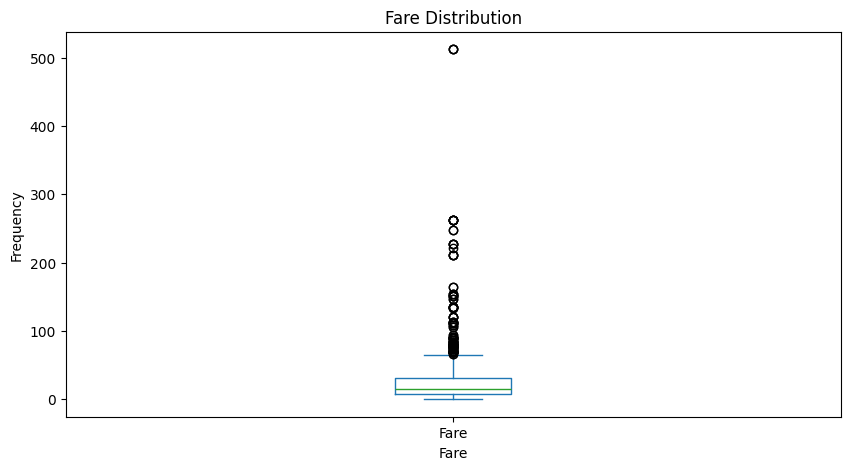

In [18]:
df['Fare'].plot(kind='box',figsize=(10,5))
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Fare Distribution')
plt.show()

In [19]:
df[df['Fare']>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


1. Through plot we conclude that Fare column has some extreme values but they are not outliers ,valid data

2. Also Fare value is not given for individual but grouped as a sum for whole family as they share same ticket no. with same price

In [20]:
#null values
df['Fare'].isnull().sum()

np.int64(0)

Fare has no null values

#Univarite on Survived Column(Categorical)

In [21]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


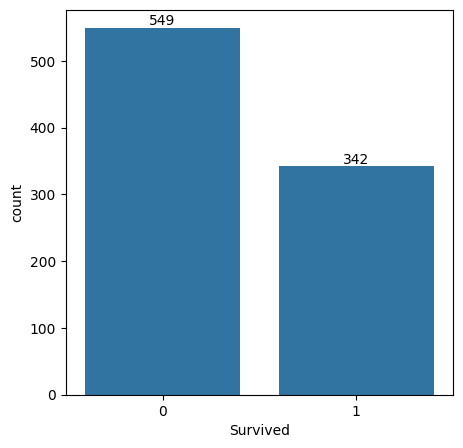

In [22]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x='Survived',data=df)
ax.bar_label(ax.containers[0])
plt.xlabel('Survived')
plt.show()


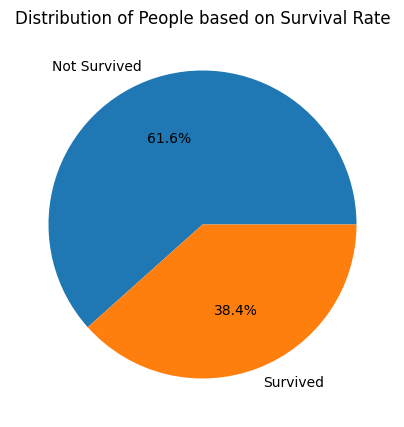

In [23]:
#in %
plt.figure(figsize=(5,5))
plt.pie(df['Survived'].value_counts(),labels=['Not Survived','Survived'],autopct='%1.1f%%')
plt.title('Distribution of People based on Survival Rate')
plt.show()


From the above chart we got to know that only 38% of total people on board survived

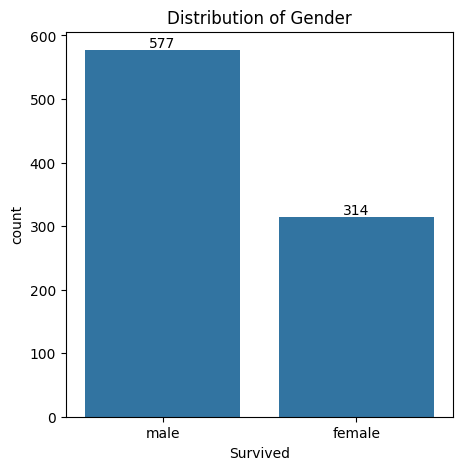

In [24]:
#Gender
plt.figure(figsize=(5,5))
ax=sns.countplot(x='Sex',data=df)
ax.bar_label(ax.containers[0])
plt.title('Distribution of Gender')
plt.xlabel('Survived')
plt.show()

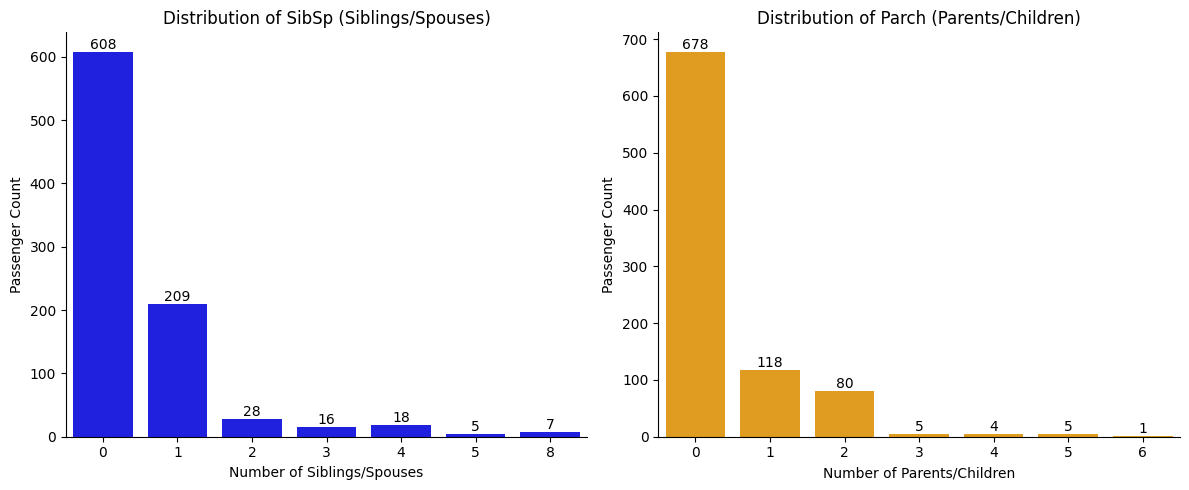

In [25]:
#distribution of Parch and SibSp  columns


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax=sns.countplot(data=df, x='SibSp', ax=axes[0], color='blue')
ax.bar_label(ax.containers[0])
axes[0].set_title('Distribution of SibSp (Siblings/Spouses)')
axes[0].set_xlabel('Number of Siblings/Spouses')
axes[0].set_ylabel('Passenger Count')

ax=sns.countplot(data=df, x='Parch', ax=axes[1], color='orange')
ax.bar_label(ax.containers[0])
axes[1].set_title('Distribution of Parch (Parents/Children)')
axes[1].set_xlabel('Number of Parents/Children')
axes[1].set_ylabel('Passenger Count')

sns.despine()
plt.tight_layout()
plt.show()

From the above analysis we conclude that Parch and SibSp columns can be merged together to form a single column Familysize

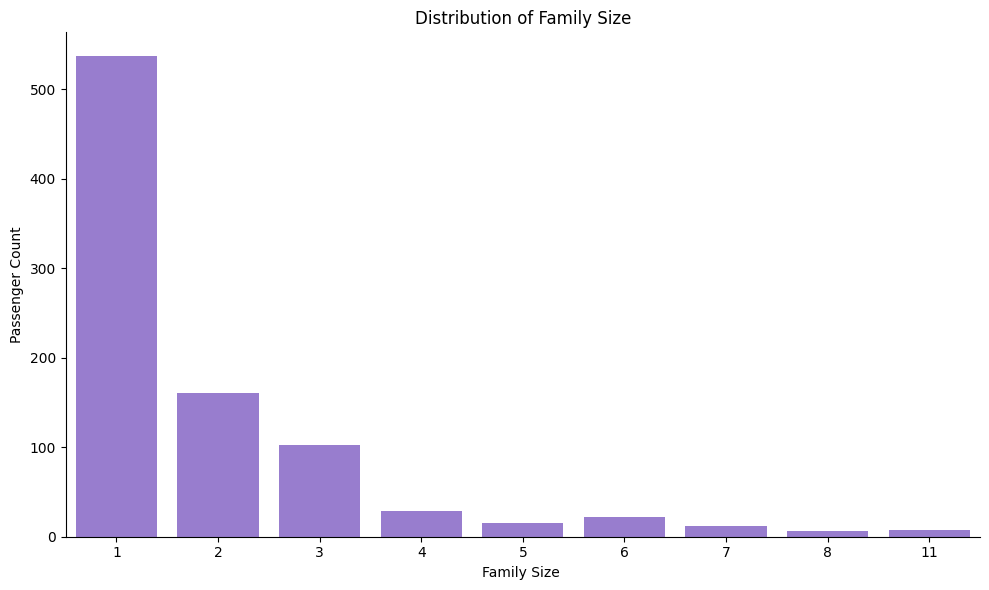

In [26]:
#Family Size

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='FamilySize', color='mediumpurple')

plt.title('Distribution of Family Size')
plt.xlabel('Family Size ')
plt.ylabel('Passenger Count')

sns.despine()
plt.tight_layout()
plt.show()

In [27]:
df['FamilySize'].describe()

,FamilySize
count,891.000000
mean,1.904602
std,1.613459
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,11.000000


In [28]:
df['FamilySize'].isnull().sum()

np.int64(0)

From the above plot we can conclude that an average passenger has atleast 1 person  as family member with maximum 11 persons

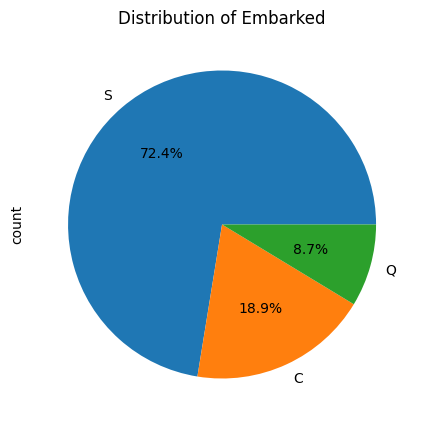

In [31]:
#Embarked
df['Embarked'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(5,5))
plt.title('Distribution of Embarked')
plt.show()

In [36]:
df['Embarked'].isnull().sum()

np.int64(0)

In [38]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isnull().sum()

np.int64(0)

In [46]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


From the above plot and analysis we conclude that majority of the passengers boarded the ship from South Hampton

##Bivariate Analysis

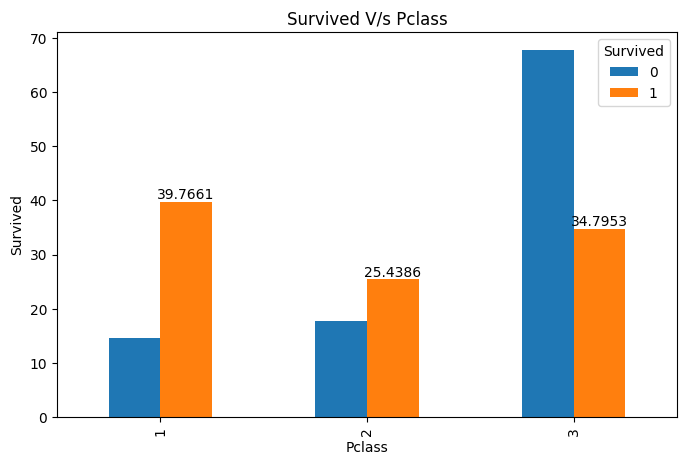

In [57]:
#BA  on Survived V/s Pclass
#using crosstab
ax=(pd.crosstab(df['Pclass'],df['Survived'],normalize='columns')*100).plot(kind='bar',figsize=(8,5))
ax.bar_label(ax.containers[1])
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.title('Survived V/s Pclass')
plt.show()

From the above plot we can clearly conclude that people travelling in Pclass 1 have the most high survival rate .

Pclass 1 is the safest class for travelling.


Pclass 3 is most risky

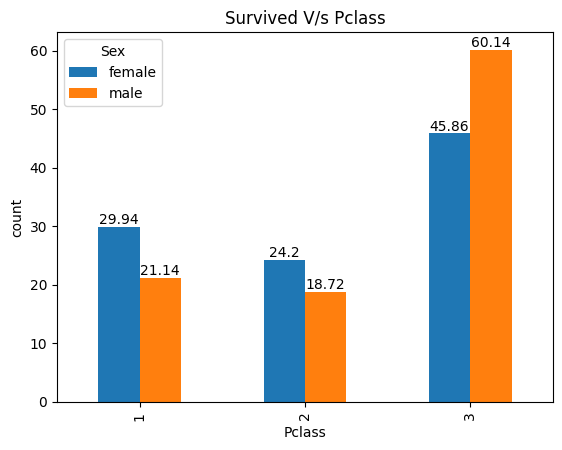

In [75]:
#Check
ax=(pd.crosstab(df['Pclass'],df['Sex'],normalize='columns')*100).round(2).plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Pclass')
plt.ylabel('count')
plt.title('Survived V/s Pclass')
plt.show()

Most passengers in Pclass1 are females making it the most safest class

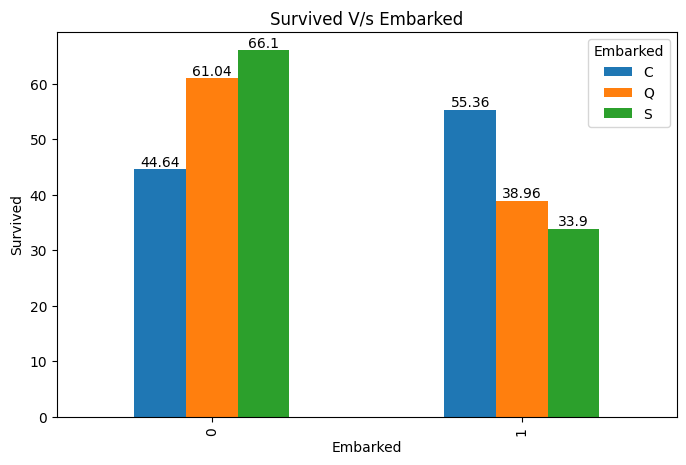

In [89]:
#Survived v/s Embarked
ax=(pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100).round(2).plot(kind='bar',figsize=(8,5))
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Embarked')
plt.ylabel('Survived')
plt.title('Survived V/s Embarked')
plt.show()

From the above graph we can conclude that people who boarded from Cebork has the highest survival rate a most people belonged to Pclass 1

In [88]:
#check
pd.crosstab(df['Pclass'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.969040
2,10.119048,3.896104,25.386997
3,39.285714,93.506494,54.643963


From this analysis we got that most passengers from Cebork are from Pclass1 that is why Cebork has a high survival rate

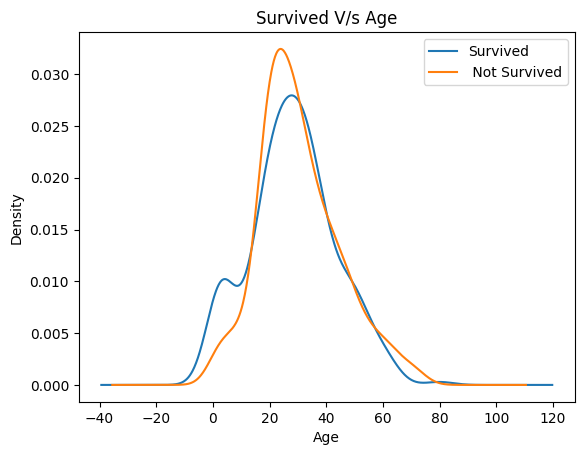

In [96]:
#survived and age
df[df['Survived']==1]['Age'].plot(kind='kde',label="Survived")
df[df['Survived']==0]['Age'].plot(kind='kde',label=" Not Survived")
plt.legend()
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Survived V/s Age')
plt.show()

From the plot we cocnclude that age is a ver important factor based on which we can predict whether a person can survive or not

With increasing age chances of survival decreases

##Column Transformation  and Analysis

In [98]:
#Family Size

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

#Labeling Family Size as a new column Family Type

In [108]:
df.loc[df['FamilySize'] == 1, 'FamilyType'] = 'Single'
df.loc[(df['FamilySize'] > 1) & (df['FamilySize'] < 5), 'FamilyType'] = 'Medium'
df.loc[df['FamilySize'] > 4, 'FamilyType'] = 'Large'

In [109]:
df['FamilyType'].value_counts()

,count
FamilyType,
Single,537
Medium,292
Large,62


In [110]:
#Survived v/s Family Type
pd.crosstab(df['Survived'],df['FamilyType'])

FamilyType,Large,Medium,Single
Survived,,,
0,52,123,374
1,10,169,163


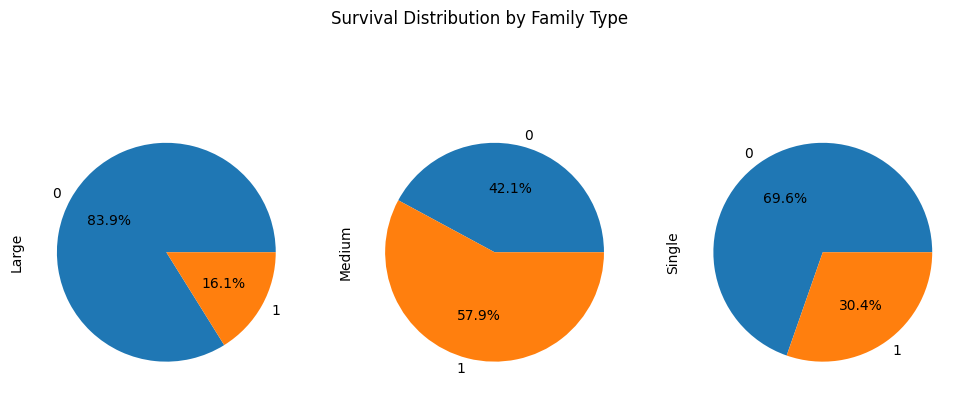

In [111]:
cross_tab = pd.crosstab(df['Survived'], df['FamilyType'])

cross_tab.plot(kind='pie', subplots=True, figsize=(12, 5), autopct='%1.1f%%', legend=False)

plt.suptitle('Survival Distribution by Family Type')
plt.show()

From the above code we can conclude that A person travelling with Medium Family Type has a higher chance of Survival

Fare Per Person

In [106]:
#Find individual Fare
df['FarePerPerson']=df['Fare']/df['FamilySize']
df['FarePerPerson'].head()


,FarePerPerson
0,3.62500
1,35.64165
2,7.92500
3,26.55000
4,8.05000


In [107]:
df['FarePerPerson'].describe()

,FarePerPerson
count,891.000000
mean,19.916375
std,35.841257
min,0.000000
25%,7.250000
50%,8.300000
75%,23.666667
max,512.329200


#Creating a new column Deck

Survived v/s Deck

In [117]:
df['Cabin'].fillna('M',inplace=True)
df['Deck']=df['Cabin'].str[0]

/tmp/ipykernel_3037/608721900.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna('M',inplace=True)


In [118]:

df['Deck'].value_counts()

,count
Deck,
M,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


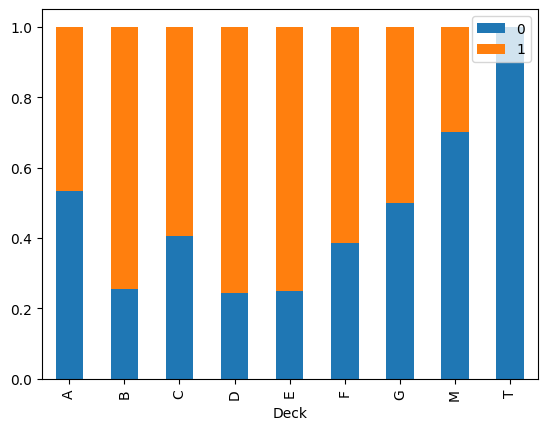

In [122]:
pd.crosstab(df['Deck'],df['Survived'],normalize='index').plot(kind='bar',stacked=True)
plt.legend()
plt.show()

In [130]:
pd.crosstab(df['Survived'],df['Deck'],normalize='columns')*100

Deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


In [129]:
pd.crosstab(df['Pclass'],df['Deck'])

Deck,A,B,C,D,E,F,G,M,T
Pclass,,,,,,,,,
1,15,47,59,29,25,0,0,40,1
2,0,0,0,4,4,8,0,168,0
3,0,0,0,0,3,5,4,479,0


##From the above analysis we can conclude that People in Deck B,C,D,E,F have more chances of survival as most of these passengers belong to Pclass1 and Pclass2